In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
def h(x):
    if x<-1 or x>1:
        y=0
    else:
        y=(np.cos(50*x)+np.sin(20*x))
    return y 

hv=np.vectorize(h) #vectorise the function

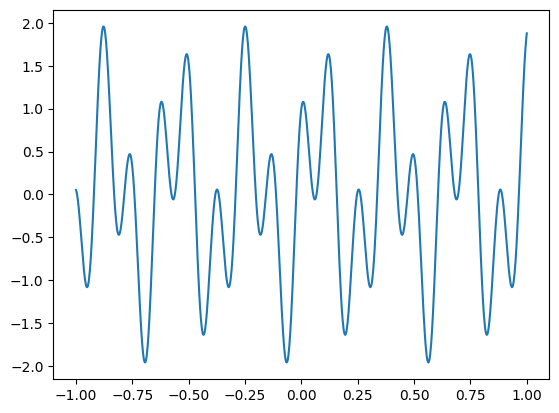

In [3]:
X=np.linspace(-1,1,num=1000)
plt.plot(X,hv(X))

In [4]:
def simple_greedy_search(func, start=0, N=100):
    x= start
    history = []
    for i in range(N):
        history.append(x) ## keep track of steps
        u=0.001 #np.random.rand() # some noise # Small step size (neighborhood)
        xleft, xright=x-u, x+u #look around the neightborhood
        yleft, yright=func(xleft), func(xright)
        if yleft>yright:
            x = xleft
        else:
            x = xright
    return x, history

In [5]:
x0, history=simple_greedy_search(hv, start=-0.02, N=100)

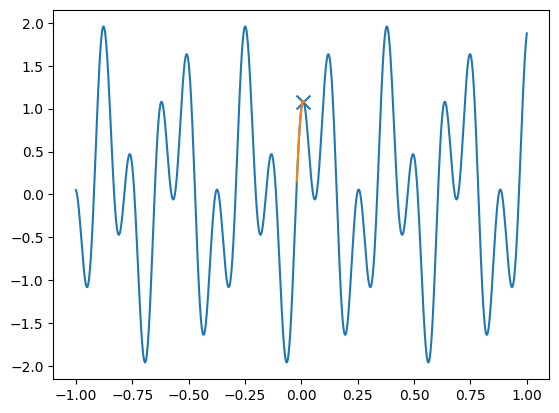

In [6]:
plt.plot(X, hv(X))

plt.scatter (x0, h(x0), marker="x", s = 100)

plt.plot(history, hv(history))

In [8]:
def SA(search_space, func, T):
    scale = np.sqrt(T) ## Suggested by Robert & Casella (Intro to MC)
    start = np.random.choice(search_space)
    x = start*1
    cur = func(x)
    history = [x]
    for i in range(1000):
        prop=x+ np.random.normal()*scale #.uniform(-1, 1, size 1) scale
        if prop > 1 or prop <0 or np.log(np.random.rand())*T> (func(prop)-cur):
            prop = x
        x = prop
        cur=func(x)
        T=0.9*T# reduce temperature by 10% each iteration
        history.append(x)
    return x, history

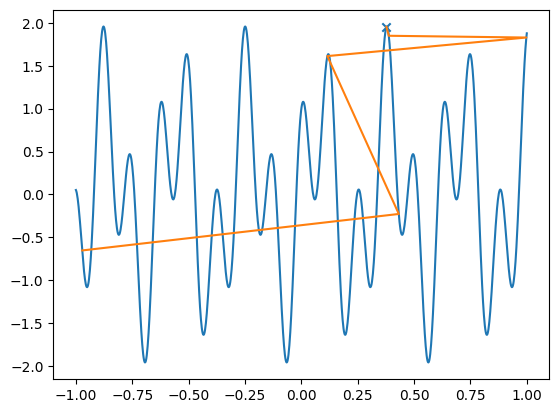

In [17]:
X = np.linspace(-1, 1, num=1000) 
x1, history =SA(X, h, T= 4)

plt.plot(X, hv(X))

plt.scatter(x1, hv(x1), marker='x')

plt.plot(history, hv (history))

In [18]:
h(history[-1])

np.float64(1.9538958336127767)